In [1]:
import random
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

import cv2
from glob import glob
from tqdm import tqdm_notebook, tnrange
from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from IPython.display import Image, display
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator





In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mateuszbuda/lgg-mri-segmentation")

print("Path to dataset files:", path)

100%|██████████| 714M/714M [00:39<00:00, 18.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2


In [3]:
print(os.listdir('/kaggle/input/lgg-mri-segmentation'))

['kaggle_3m', 'lgg-mri-segmentation']


In [4]:
print(os.listdir('/kaggle/input/lgg-mri-segmentation/kaggle_3m'))

['TCGA_DU_7010_19860307', 'TCGA_DU_8162_19961029', 'TCGA_FG_A4MT_20020212', 'TCGA_FG_5964_20010511', 'TCGA_DU_A5TS_19970726', 'TCGA_HT_7692_19960724', 'TCGA_DU_5849_19950405', 'TCGA_FG_A60K_20040224', 'TCGA_HT_7475_19970918', 'TCGA_FG_6691_20020405', 'TCGA_HT_7684_19950816', 'TCGA_CS_6188_20010812', 'TCGA_HT_7694_19950404', 'TCGA_DU_A5TR_19970726', 'TCGA_DU_7300_19910814', 'TCGA_DU_7018_19911220', 'TCGA_DU_7301_19911112', 'TCGA_DU_7302_19911203', 'TCGA_HT_8018_19970411', 'TCGA_FG_6692_20020606', 'TCGA_DU_5854_19951104', 'TCGA_DU_7299_19910417', 'TCGA_HT_A5RC_19990831', 'TCGA_HT_8105_19980826', 'TCGA_HT_8563_19981209', 'TCGA_HT_A61A_20000127', 'TCGA_CS_4944_20010208', 'TCGA_FG_7643_20021104', 'TCGA_DU_8163_19961119', 'TCGA_CS_6669_20020102', 'TCGA_DU_7013_19860523', 'TCGA_FG_8189_20030516', 'TCGA_HT_8111_19980330', 'TCGA_CS_5396_20010302', 'TCGA_DU_7294_19890104', 'TCGA_HT_7879_19981009', 'README.md', 'TCGA_EZ_7264_20010816', 'TCGA_DU_8164_19970111', 'TCGA_HT_7860_19960513', 'TCGA_HT_78

In [5]:
print(os.listdir('/kaggle/input/lgg-mri-segmentation/kaggle_3m/TCGA_DU_7301_19911112'))

['TCGA_DU_7301_19911112_10.tif', 'TCGA_DU_7301_19911112_27_mask.tif', 'TCGA_DU_7301_19911112_22_mask.tif', 'TCGA_DU_7301_19911112_20_mask.tif', 'TCGA_DU_7301_19911112_4_mask.tif', 'TCGA_DU_7301_19911112_29_mask.tif', 'TCGA_DU_7301_19911112_19_mask.tif', 'TCGA_DU_7301_19911112_29.tif', 'TCGA_DU_7301_19911112_12.tif', 'TCGA_DU_7301_19911112_15_mask.tif', 'TCGA_DU_7301_19911112_11.tif', 'TCGA_DU_7301_19911112_1_mask.tif', 'TCGA_DU_7301_19911112_31_mask.tif', 'TCGA_DU_7301_19911112_21_mask.tif', 'TCGA_DU_7301_19911112_6.tif', 'TCGA_DU_7301_19911112_33.tif', 'TCGA_DU_7301_19911112_30_mask.tif', 'TCGA_DU_7301_19911112_7_mask.tif', 'TCGA_DU_7301_19911112_30.tif', 'TCGA_DU_7301_19911112_5.tif', 'TCGA_DU_7301_19911112_1.tif', 'TCGA_DU_7301_19911112_13_mask.tif', 'TCGA_DU_7301_19911112_28.tif', 'TCGA_DU_7301_19911112_14.tif', 'TCGA_DU_7301_19911112_25_mask.tif', 'TCGA_DU_7301_19911112_18_mask.tif', 'TCGA_DU_7301_19911112_16.tif', 'TCGA_DU_7301_19911112_18.tif', 'TCGA_DU_7301_19911112_23.tif', 'T

In [6]:
IMG_WIDTH = 256
IMG_HEIGHT = 256

image_filename_train = []
mask_files = glob(os.path.join(path, 'kaggle_3m',"*","*_mask.tif"))

In [7]:
for i in  mask_files:
  image_filename_train.append(i.replace("_mask",""))

In [8]:
print(image_filename_train)
print(len(image_filename_train))

['/root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m/TCGA_HT_8563_19981209/TCGA_HT_8563_19981209_20.tif', '/root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m/TCGA_HT_8563_19981209/TCGA_HT_8563_19981209_22.tif', '/root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m/TCGA_HT_8563_19981209/TCGA_HT_8563_19981209_21.tif', '/root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m/TCGA_HT_8563_19981209/TCGA_HT_8563_19981209_8.tif', '/root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m/TCGA_HT_8563_19981209/TCGA_HT_8563_19981209_23.tif', '/root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m/TCGA_HT_8563_19981209/TCGA_HT_8563_19981209_16.tif', '/root/.cache/kagglehub/datasets/mateuszbuda/lgg-mri-segmentation/versions/2/kaggle_3m/TCGA_HT_8563_19981209/TCGA_HT_8563_19981209_13.tif', '/root/.cache/kaggle

In [9]:
def plot_from_img_path(rows, cols, list_img_path, list_mask_path):
    fig = plt.figure(figsize=(12, 12))
    total = rows * cols
    for i in range(total):
        fig.add_subplot(rows, cols, i + 1)
        img_path = list_img_path[i]
        mask_path = list_mask_path[i]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path)
        plt.imshow(image)
        plt.imshow(mask, alpha=0.4)
    plt.show()

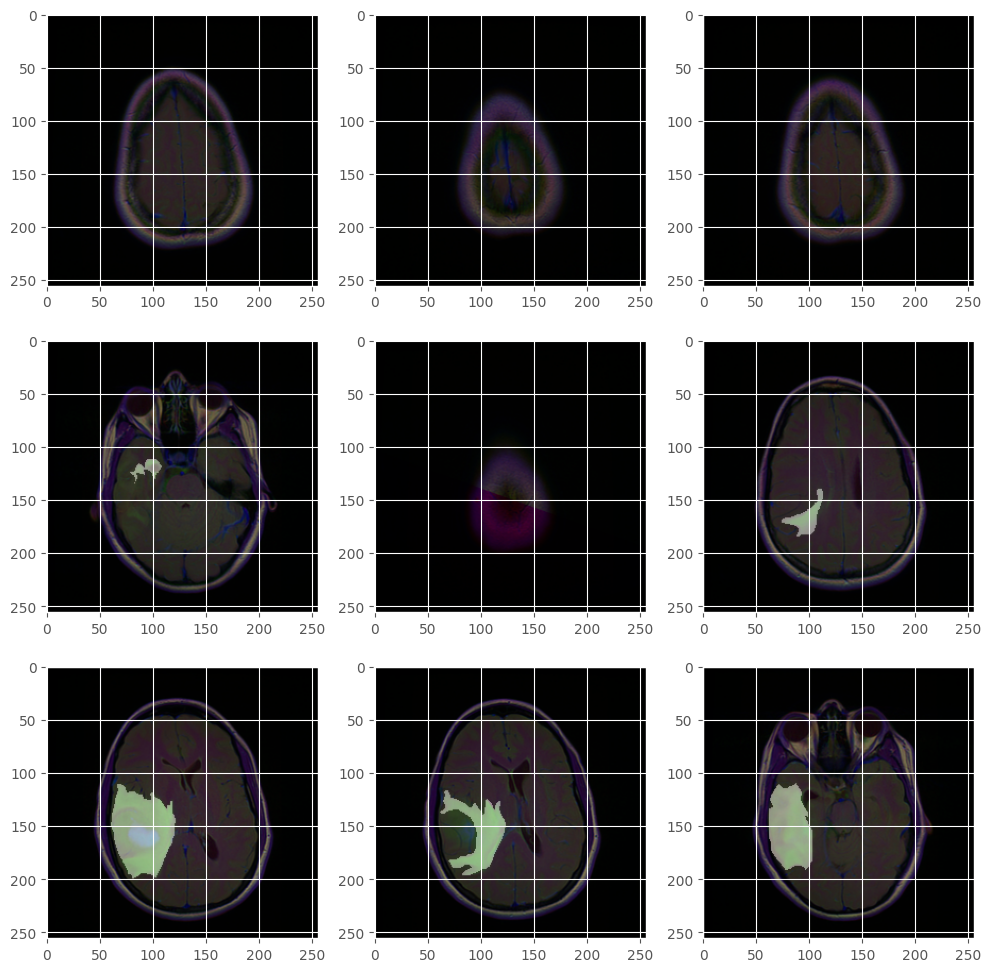

In [10]:
plot_from_img_path(3,3,image_filename_train, mask_files )

In [11]:
df = pd.DataFrame(data = {'image_filename_train':image_filename_train, 'mask':mask_files})

In [12]:
df_train, df_test= train_test_split(df, test_size=0.05)
df_train, df_valid= train_test_split(df_train, test_size=0.05)

print(df_train.shape)
print(df_valid.shape)
print(df_test.shape)

(3545, 2)
(187, 2)
(197, 2)


In [13]:
def normalize_and_diagnose(img, mask):
    img = img.astype(np.float32) / 255.0
    mask = mask.astype(np.float32) / 255.0
    mask = (mask > 0.5).astype(np.float32)
    img = tf.where(tf.math.is_nan(img), tf.zeros_like(img), img)
    mask = tf.where(tf.math.is_nan(mask), tf.zeros_like(mask), mask)
    return img, mask

In [14]:
def train_generator(data_frame, batch_size, augmentation_dict, image_color_mode='rgb', mask_color='grayscale', image_save_prefix="image",mask_save_prefix="mask", save_to_dir=None, target_size=(256,256), seed=1):
  image_datagen = ImageDataGenerator(**augmentation_dict)
  mask_datagen = ImageDataGenerator(**augmentation_dict)
  image_generator = image_datagen.flow_from_dataframe(
      data_frame,
      x_col = 'image_filename_train',
      class_mode = None,
      color_mode = image_color_mode,
      target_size = target_size,
      batch_size=batch_size,
      save_to_dir = save_to_dir,
      save_prefix = image_save_prefix,
      seed = seed


  )
  mask_generator = mask_datagen.flow_from_dataframe(
      data_frame,
      x_col = 'mask',
      class_mode = None,
      color_mode = mask_color,
      target_size = target_size,
      batch_size=batch_size,
      save_to_dir = save_to_dir,
      save_prefix = mask_save_prefix,
      seed = seed
  )
  train_gen = zip(image_generator, mask_generator)
  for img, mask in train_gen:
    img, mask = normalize_and_diagnose(img, mask)
    yield (img, mask)

In [15]:
def dice_coefficients(y_true, y_pred, smooth = 1e-6):
  y_true_flatten = K.flatten(y_true)
  y_pred_flatten = K.flatten(y_pred)
  intersection = K.sum(y_true_flatten * y_pred_flatten)
  union = K.sum(y_true_flatten) + K.sum(y_pred_flatten)
  return (2. * intersection+smooth) / (union+smooth)

def dice_coefficients_loss(y_true, y_pred, smooth=1e-6):
  return -dice_coefficients(y_true, y_pred)

def iou(y_true, y_pred, smooth=1e-6):
  intersection = K.sum(y_true * y_pred)
  sum = K.sum(y_true + y_pred)
  iou = (intersection + smooth) / (sum - intersection + smooth)
  return iou

def jaccard_distance(y_true, y_pred):
  y_true_flatten = K.flatten(y_true)
  y_pred_flatten = K.flatten(y_pred)
  return iou(y_true_flatten, y_pred_flatten)

In [16]:
def unet(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)):
    inputs = Input(input_shape)

    # Encoder
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(inputs)
    conv1 = Conv2D(64, 3, activation='relu', padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2,2))(conv1)

    conv2 = Conv2D(128, 3, activation='relu', padding='same')(pool1)
    conv2 = Conv2D(128, 3, activation='relu', padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2,2))(conv2)

    conv3 = Conv2D(256, 3, activation='relu', padding='same')(pool2)
    conv3 = Conv2D(256, 3, activation='relu', padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2,2))(conv3)

    conv4 = Conv2D(512, 3, activation='relu', padding='same')(pool3)
    conv4 = Conv2D(512, 3, activation='relu', padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2,2))(conv4)

    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(pool4)
    conv5 = Conv2D(1024, 3, activation='relu', padding='same')(conv5)

    # Decoder
    up6 = Conv2DTranspose(512, 2, strides=(2,2), padding='same')(conv5)
    up6 = concatenate([up6, conv4])
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(up6)
    conv6 = Conv2D(512, 3, activation='relu', padding='same')(conv6)

    up7 = Conv2DTranspose(256, 2, strides=(2,2), padding='same')(conv6)
    up7 = concatenate([up7, conv3])
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(up7)
    conv7 = Conv2D(256, 3, activation='relu', padding='same')(conv7)

    up8 = Conv2DTranspose(128, 2, strides=(2,2), padding='same')(conv7)
    up8 = concatenate([up8, conv2])
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(up8)
    conv8 = Conv2D(128, 3, activation='relu', padding='same')(conv8)

    up9 = Conv2DTranspose(64, 2, strides=(2,2), padding='same')(conv8)
    up9 = concatenate([up9, conv1])
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(up9)
    conv9 = Conv2D(64, 3, activation='relu', padding='same')(conv9)

    outputs = Conv2D(1, 1, activation='sigmoid')(conv9)

    model = Model(inputs=inputs, outputs=outputs)
    return model

In [17]:
EPOCHS = 50
BATCH_SIZE = 32
lr = 1e-4

train_generator_args = dict(
    rotation_range=0.2,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)
train_gen= train_generator(df_train, BATCH_SIZE, train_generator_args, target_size=(IMG_WIDTH, IMG_HEIGHT))
test_gen= train_generator(df_test, BATCH_SIZE,dict() ,target_size=(IMG_WIDTH, IMG_HEIGHT))

In [18]:
model = unet(input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

In [19]:
model.compile(optimizer=Adam(learning_rate=lr),
              loss='binary_crossentropy',
              metrics=[iou, dice_coefficients])
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
callbacks = [ModelCheckpoint('unet.keras', save_best_only=True), early_stop]

history = model.fit(train_gen,
                    steps_per_epoch=len(df_train) // BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=test_gen,
                    validation_steps=len(df_test) // BATCH_SIZE,
                    callbacks=callbacks)

Found 3545 validated image filenames.
Found 3545 validated image filenames.
Epoch 1/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - dice_coefficients: 0.0194 - iou: 0.0099 - loss: 0.3764Found 197 validated image filenames.
Found 197 validated image filenames.
110/110 ━━━━━━━━━━━━━━━━━━━━ 443s 2s/step - dice_coefficients: 0.0460 - iou: 0.0242 - loss: 0.1795 - val_dice_coefficients: 0.1237 - val_iou: 0.0662 - val_loss: 0.0242
Epoch 2/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - dice_coefficients: 0.2043 - iou: 0.1151 - loss: 0.0293 - val_dice_coefficients: 0.2209 - val_iou: 0.1254 - val_loss: 0.0211
Epoch 3/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 221s 2s/step - dice_coefficients: 0.2784 - iou: 0.1646 - loss: 0.0276 - val_dice_coefficients: 0.3612 - val_iou: 0.2238 - val_loss: 0.0222
Epoch 4/50
110/110 ━━━━━━━━━━━━━━━━━━━━ 281s 3s/step - dice_coefficients: 0.3648 - iou: 0.2275 - loss: 0.0257 - val_dice_coefficients: 0.2542 - val_iou: 0.1509 - val_loss: 0.0301
Epoch 5/50
110/110 ━━━━━━━━━━━━━━━━━━━

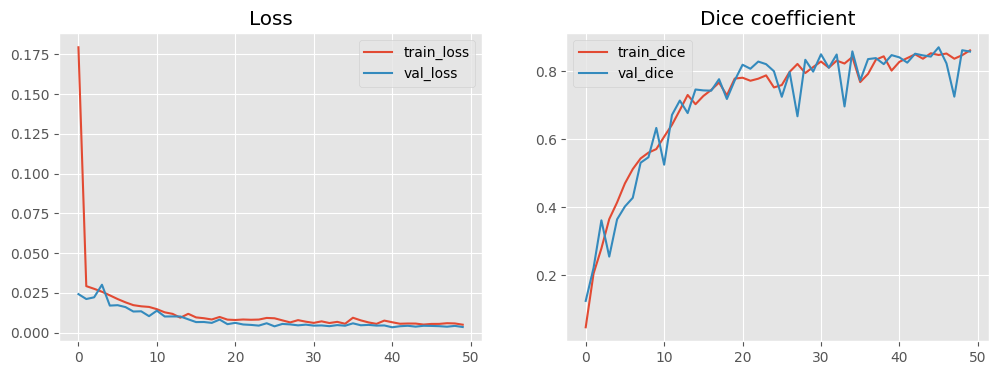

In [20]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['dice_coefficients'], label='train_dice')
plt.plot(history.history['val_dice_coefficients'], label='val_dice')
plt.legend()
plt.title('Dice coefficient')
plt.show()

In [21]:

best_model = load_model('unet.keras', custom_objects={
    'dice_coefficients': dice_coefficients,
    'iou': iou
})

test_gen = train_generator(df_test, BATCH_SIZE, {}, target_size=(IMG_WIDTH, IMG_HEIGHT))
test_loss, test_iou, test_dice = best_model.evaluate(test_gen, steps=len(df_test)//BATCH_SIZE)
print(f"Test Loss: {test_loss:.4f}, Test IoU: {test_iou:.4f}, Test Dice: {test_dice:.4f}")

Found 197 validated image filenames.
Found 197 validated image filenames.
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 747ms/step - dice_coefficients: 0.8575 - iou: 0.7515 - loss: 0.0037
Test Loss: 0.0037, Test IoU: 0.7515, Test Dice: 0.8575


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


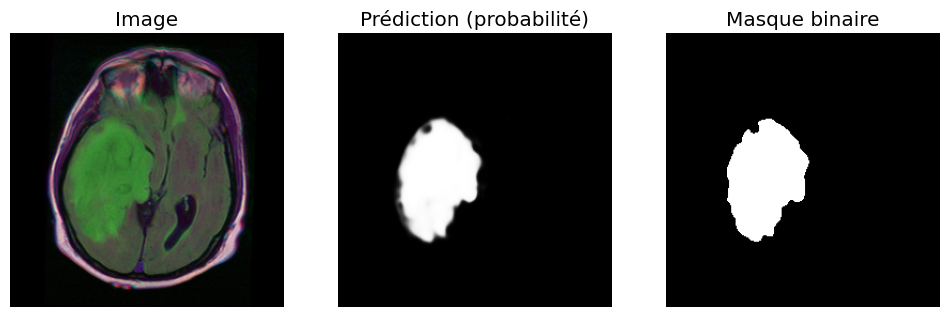

In [22]:
def display_prediction(model, img_path, mask_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
    pred = model.predict(np.expand_dims(img_resized, axis=0))[0, :, :, 0]
    pred_bin = (pred > 0.5).astype(np.uint8)

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1); plt.imshow(img_resized); plt.title('Image'); plt.axis('off')
    plt.subplot(1,3,2); plt.imshow(pred, cmap='gray'); plt.title('Prédiction (probabilité)'); plt.axis('off')
    plt.subplot(1,3,3); plt.imshow(pred_bin, cmap='gray'); plt.title('Masque binaire'); plt.axis('off')
    plt.show()

# Exemple avec une image de test
sample_row = df_test.iloc[0]
display_prediction(best_model, sample_row['image_filename_train'], sample_row['mask'])